# 01 — Bigram baseline

The bigram model predicts the next character from the **current character alone**: a single `(vocab, vocab)` lookup table whose row *i* is the logit distribution over the next character given character *i*. No context, no attention, no hidden state.

Its converged loss is the floor set by the corpus's first-order character statistics — the number every later ingredient must beat. We train it to convergence (it plateaus well before 20k steps) so the baseline is honest rather than under-trained.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import torch, matplotlib.pyplot as plt
from gpt import make_dataset, train, generate, set_seed, TrainConfig

ds = make_dataset()
print("vocab:", ds.vocab_size, "| train tokens:", len(ds.train_data), "| val tokens:", len(ds.val_data))

vocab: 65 | train tokens: 1003854 | val tokens: 111540


In [2]:
from models import BigramLanguageModel

g = set_seed(1337)
model = BigramLanguageModel(ds.vocab_size)
print(sum(p.numel() for p in model.parameters()), "parameters")

cfg = TrainConfig(max_iters=20000, eval_interval=1000, eval_iters=200, batch_size=16)
history = train(model, ds, block_size=8, cfg=cfg, generator=g)

4225 parameters


step 0: train loss 4.7203, val loss 4.7192


step 1000: train loss 3.8135, val loss 3.8158


step 2000: train loss 3.2319, val loss 3.2352


step 3000: train loss 2.8951, val loss 2.8973


...

step 16000: train loss 2.4615, val loss 2.4732


step 17000: train loss 2.4606, val loss 2.4732


step 18000: train loss 2.4598, val loss 2.4724


step 19000: train loss 2.4594, val loss 2.4731


step 19999: train loss 2.4590, val loss 2.4738


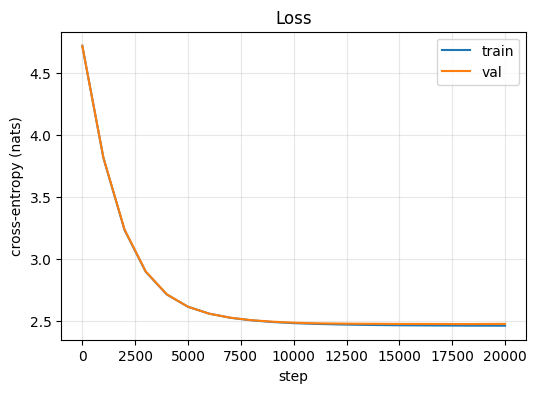

final: {'step': 19999, 'train': 2.459041118621826, 'val': 2.473757743835449}


TINCHAncaveotave heand kert his he be; larorirkengherbe utobungoeved?
GUG ack,
COWhapens har the, pers paly lom, phe mou wid pt hath omabepan pielego le rd IUENTY:
Fis ran s, o ig rd.
che knd etndof orrea ch wo fe; it
n fes pimeistheer Basthindshatr'd n ama rom bre pon?
g aven yche byo-t h po
An! t


In [3]:
steps = [h["step"] for h in history]
plt.figure(figsize=(6,4))
plt.plot(steps, [h["train"] for h in history], label="train")
plt.plot(steps, [h["val"] for h in history], label="val")
plt.xlabel("step"); plt.ylabel("cross-entropy (nats)"); plt.legend()
plt.title("Loss"); plt.grid(alpha=0.3); plt.show()
print("final:", history[-1])

# sample
out = model.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=300)
print(ds.tokenizer.decode(out[0].tolist()))

**Takeaway.** The bigram converges to a val loss of about **2.48 nats**. The samples have the right character frequencies and occasional real bigrams, but no word structure — the model cannot see beyond one character, so it cannot assemble words, let alone lines. Everything that follows is an attempt to give the model *context*.